# Opis

Notatnik służący do wszelkich wizualizacji wyników itp.

# Importy

In [1]:
%load_ext autoreload
%autoreload 2
import json
import matplotlib.pyplot as plt

import sys


sys.path.append('../')
import torch
from utils.FramsticksGraphDataset import FramsticksGraphDataset
from pyprojroot import here
from src.models.KlejdaGAE.GraphAutoencoder import GraphAutoencoder
from src.models.KlejdaGAE.VariationalGraphAutoencoder import VariationalGraphAutoencoder

import yaml
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

import plotly.express as px
import pandas as pd

C:\Users\witek\PycharmProjects\Magisterka\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
current_dir = os.getcwd()
framspy_path = os.path.abspath(os.path.join(current_dir, '..', 'external', 'framspy'))
if framspy_path not in sys.path:
	sys.path.insert(0, framspy_path)
with open("../configs/final_evolution_config.yaml", 'r') as f:
	evolution_config = yaml.safe_load(f)
import frams

frams.init(
    evolution_config['frams_path']
)

Using Framsticks version: 5.5
Home (writable) dir     : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data
Resources dir           : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data



# Histogram rozkładu osobników w zbiorze danych (fitness i parts_num)

In [3]:
genotypes = []
with open("../results/sampled_best_individuals_merged.jsonl", "r", encoding="utf-8") as f:
	for line in f:
		obj = json.loads(line.strip())
		genotypes.append(obj)

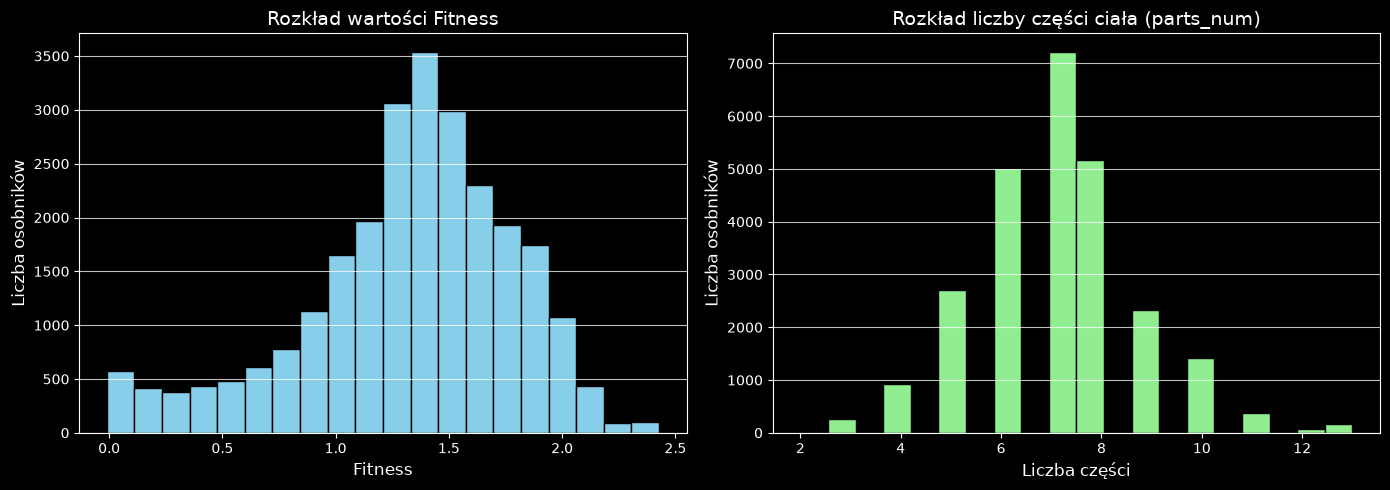

In [4]:
fitness_values = []
parts_nums = []

for obj in genotypes:
	# 1. Pobranie wartości fitness (wyciągamy pierwszy element z listy)
	fitness = obj["fitness"][0]
	if fitness < -1:
		continue
	fitness_values.append(fitness)

	# 2. Zliczanie wierszy zaczynających się od 'p:' w genotypie
	genotype_str = obj["genotype"]
	parts_count = sum(1 for line in genotype_str.strip().split('\n') if line.startswith('p:'))
	parts_nums.append(parts_count)

x_bins = 20 # Liczba kubełków w histogramie

# Tworzymy figurę z dwoma wykresami obok siebie (1 wiersz, 2 kolumny)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# --- Pierwszy wykres: Fitness ---
axes[0].hist(fitness_values, bins=x_bins, color='skyblue', edgecolor='black')
axes[0].set_title('Rozkład wartości Fitness', fontsize=14)
axes[0].set_xlabel('Fitness', fontsize=12)
axes[0].set_ylabel('Liczba osobników', fontsize=12)
axes[0].grid(axis='y', alpha=0.75)

# --- Drugi wykres: Liczba części (parts_num) ---
axes[1].hist(parts_nums, bins=x_bins, color='lightgreen', edgecolor='black')
axes[1].set_title('Rozkład liczby części ciała (parts_num)', fontsize=14)
axes[1].set_xlabel('Liczba części', fontsize=12)
axes[1].set_ylabel('Liczba osobników', fontsize=12)
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

# Wizualizacja przestrzeni ukrytej

In [5]:
project_dir = here()
# Przygotowanie checkpointów nauczonych autoenkoderów
checkpoints_dir = project_dir / 'notebooks' / 'checkpoints' / 'final_checkpoints' / 'klejda'
checkpoint_gae = torch.load(checkpoints_dir / 'gae.ckpt')
checkpoint_vgae = torch.load(checkpoints_dir / 'vgae.ckpt')
# Przygotowanie konfiguracji dla gae
configs_dir = project_dir / 'configs'
config_gae_path = configs_dir / 'klejda_gae_config.yaml'
config_vgae_path = configs_dir / 'klejda_vgae_config.yaml'
with open(config_gae_path) as f:
	config_gae = yaml.safe_load(f)
with open(config_vgae_path) as f:
	config_vgae = yaml.safe_load(f)
torch.set_printoptions(precision=10)

In [6]:
# Przygotowanie macierzy wektorów ukrytych
# dataset = FramsticksDummyDataset(num_samples=1000)
NUMBER_OF_EXAMPLES = 4000
genotypes = []
with open("../results/sampled_individuals_better.jsonl", "r", encoding="utf-8") as f:
	for line in f:
		obj = json.loads(line.strip())
		genotypes.append(obj)

dataset = FramsticksGraphDataset(genotypes, config_gae["max_nodes"])
dataset_size = len(dataset)

dataloader = DataLoader(
	dataset,
	batch_size=1,
	shuffle=True,
	num_workers=2,
	persistent_workers=True
)

gae_non_cyclic = GraphAutoencoder(config=config_gae, frams_module=frams).double()
gae_non_cyclic.load_state_dict(checkpoint_gae['state_dict'])
gae_non_cyclic.eval()

latent_vectors = []
labels = []

# Wyłączenie obliczania gradientów
with torch.no_grad():
	for i, batch in enumerate(dataloader):
		if i >= NUMBER_OF_EXAMPLES:
			break

		# Rozpakowanie batcha
		x_matrix = batch[0]
		a_matrix = batch[1]
		label = batch[2][config_gae['locality_loss_type']].squeeze(0).tolist()
		if config_gae['locality_loss_type'] == 'fitness':
			label = label[0]
		labels.append(label)

		device = next(gae_non_cyclic.parameters()).device
		x_matrix = x_matrix.to(device)
		a_matrix = a_matrix.to(device)

		z = gae_non_cyclic.encode(x_matrix, a_matrix)

		# Spakowanie do batcha
		z_single = z.squeeze(0).cpu()

		latent_vectors.append(z_single)
latent_vectors = np.array(latent_vectors)
print(f"Pomyślnie wygenerowano {len(latent_vectors)} wektorów ukrytych.")
# Przykładowy podgląd kształtu pierwszego wektora
print(f"Kształt pojedynczego wektora z: {latent_vectors[0].shape}")
# print(f"Labels: {labels}")

Pomyślnie wygenerowano 4000 wektorów ukrytych.
Kształt pojedynczego wektora z: (10,)


## Metoda WDW (bardzo wolna optymalizacja)

In [42]:
def generate_point_cloud(num_points, dimensions, min_value, max_value):
	'''Generuje pierwotne punkty, których macierz dystansów będzie optymalizowana'''
	res = np.zeros([num_points, dimensions])
	for i in range(num_points):
		point = np.zeros([dimensions])
		for j in range(dimensions):
			point[j] = np.random.uniform(min_value, max_value)
		res[i, :] = point
	return res


def generate_distance_matrix(points):
	'''Generuje macierz dystansów dla podanych punktów'''
	distance_matrix = np.zeros([points.shape[0], points.shape[0]])
	for i in range(points.shape[0]):
		x = points[i]
		for j in range(points.shape[0]):
			y = points[j]
			x_minus_y = x - y
			distance_matrix[i, j] = np.sqrt(x_minus_y @ x_minus_y.T)
	return distance_matrix


def calculate_frobenius_norm(matA, matB):
	assert matA.shape == matB.shape
	return np.sqrt(np.sum(np.square(matA - matB).flatten()))


def optimize_matrix(distance_matrix):
	'''Optymalizacja macierzy dystansów poprzez przestawianie punktów z wykorzystaniem optymalizatora'''

	def func(mat):
		mat = np.reshape(mat, [distance_matrix.shape[0], 2])
		dist_mat = generate_distance_matrix(mat)
		return calculate_frobenius_norm(dist_mat, distance_matrix)

	resX = generate_point_cloud(num_points=distance_matrix.shape[0], dimensions=2, min_value=-2, max_value=2).flatten()
	return optimize.minimize(func, resX)


def visualize_2d_points(points, loss, labels):
    '''Wizualizacja punktów w przestrzeni dwuwymiarowej'''
    assert points.shape[1] == 2, "Tablica punktów musi mieć wymiary (N, 2)"
    assert len(points) == len(labels), "Liczba punktów musi odpowiadać liczbie etykiet"

    plt.figure(figsize=(8, 6))

    x_coords = points[:, 0]
    y_coords = points[:, 1]

    # Rysowanie punktów - kolor i styl pozostawione bez zmian
    plt.scatter(x_coords, y_coords, c='blue', marker='o', edgecolors='k', alpha=0.7)

    # Pętla dodająca etykiety do każdego punktu
    for i, label in enumerate(labels):
        plt.annotate(
            str(label),                 # Konwersja na string, na wypadek gdyby to były liczby
            (x_coords[i], y_coords[i]), # Dokładna pozycja punktu
            textcoords="offset points", # Ustawienie tekstu z przesunięciem
            xytext=(5, 5),              # Przesunięcie o 5 pikseli w prawo i w górę
            ha='left',                  # Wyrównanie do lewej
            fontsize=9,                 # Rozmiar czcionki (możesz dostosować)
            alpha=0.9                   # Lekka przezroczystość, by nie dominowało nad wykresem
        )

    plt.title(f'Wizualizacja 2D (Frobenius norm loss: {loss:.2f})')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


# distance_matrix = generate_distance_matrix(latent_vectors)
# num_points = distance_matrix.shape[0]
#
# print(f"Optymalizowanie normy Frobeniusa ...")
# optimization_result = optimize_matrix(distance_matrix)
# # print(optimize_matrix(distance_matrix))
# res_points = np.array(optimization_result.x).reshape(num_points, 2)
# frobenius_norm_loss = optimization_result.fun
# print("Przygotowywanie wizualizacji ...")
# visualize_2d_points(res_points, frobenius_norm_loss, labels)




Optymalizowanie normy Frobeniusa ...


KeyboardInterrupt: 

## PCA 2D

Generowanie wizualizacji PCA dla fitnessu...


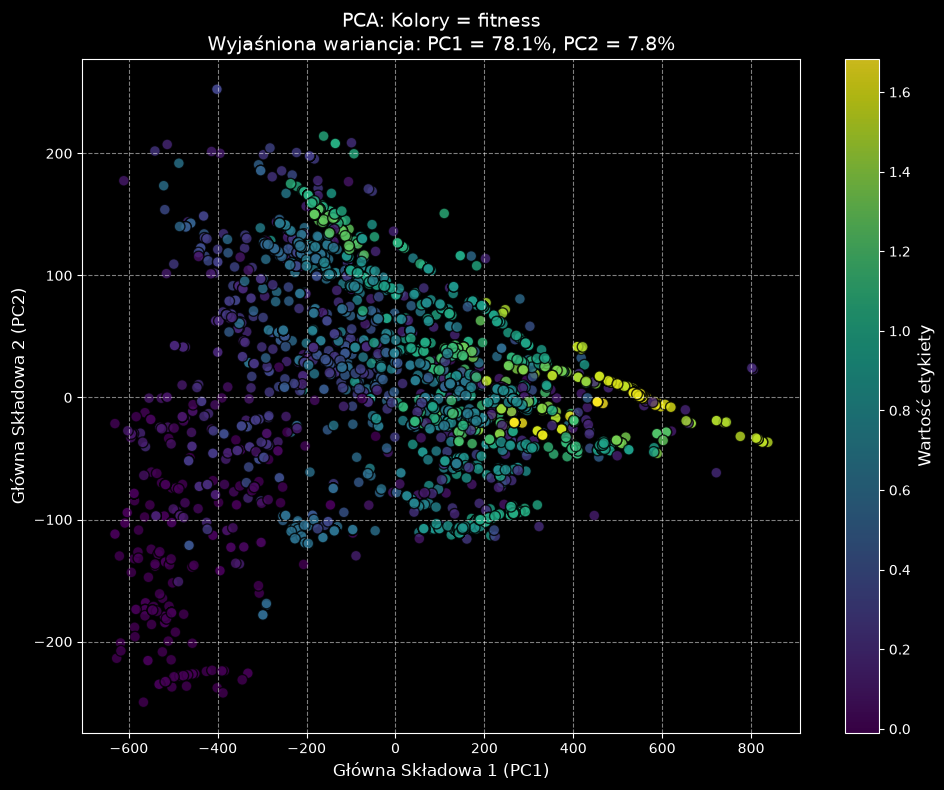

In [7]:
def visualize_pca_2d(latent_vectors, labels, title="Wizualizacja PCA przestrzeni ukrytej (2D)"):
    # 1. Konwersja listy tensorów PyTorch na jedną, płaską macierz Numpy
    if isinstance(latent_vectors[0], torch.Tensor):
        z_matrix = torch.stack(latent_vectors).detach().cpu().numpy()
    else:
        z_matrix = np.array(latent_vectors)

    labels = np.array(labels)

    assert len(z_matrix) == len(labels), "Liczba wektorów i etykiet musi być identyczna!"

    pca = PCA(n_components=2)
    z_pca = pca.fit_transform(z_matrix)

    explained_variance = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(10, 8))

    # Wykres punktowy
    scatter = plt.scatter(
        z_pca[:, 0],
        z_pca[:, 1],
        c=labels,
        cmap='viridis',
        marker='o',
        edgecolors='black',
        alpha=0.8,
        s=60
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label('Wartość etykiety', fontsize=12)

    # for i, label in enumerate(labels):
    #     formatted_label = f"{label:.2f}" if isinstance(label, float) else str(label)
	#
    #     plt.annotate(
    #         formatted_label,
    #         (z_pca[i, 0], z_pca[i, 1]),
    #         textcoords="offset points",
    #         xytext=(5, 4),
    #         ha='left',
    #         fontsize=8,
    #         alpha=0.95
    #     )

    plt.title(f'{title}\nWyjaśniona wariancja: PC1 = {explained_variance[0]:.1f}%, PC2 = {explained_variance[1]:.1f}%', fontsize=14)
    plt.xlabel(f'Główna Składowa 1 (PC1)', fontsize=12)
    plt.ylabel(f'Główna Składowa 2 (PC2)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

print("Generowanie wizualizacji PCA dla fitnessu...")
visualize_pca_2d(latent_vectors, labels, title=f"PCA: Kolory = {config_gae['locality_loss_type']}")


## PCA 3D

In [8]:
def visualize_pca_3d_interactive(latent_vectors, labels, title="Interaktywne PCA 3D"):
    if isinstance(latent_vectors[0], torch.Tensor):
        z_matrix = torch.stack(latent_vectors).detach().cpu().numpy()
    else:
        z_matrix = np.array(latent_vectors)

    labels = np.array(labels)
    assert len(z_matrix) == len(labels), "Liczba wektorów i etykiet musi być identyczna!"

    pca = PCA(n_components=3)
    z_pca = pca.fit_transform(z_matrix)
    exp_var = pca.explained_variance_ratio_ * 100

    hover_texts = [f"Wartość: {lbl:.3f}" if isinstance(lbl, float) else f"Wartość: {lbl}" for lbl in labels]

    df = pd.DataFrame({
        'PC1': z_pca[:, 0],
        'PC2': z_pca[:, 1],
        'PC3': z_pca[:, 2],
        'Etykieta': labels,
        'Szczegóły': hover_texts
    })

    fig = px.scatter_3d(
        df,
        x='PC1',
        y='PC2',
        z='PC3',
        color='Etykieta',          # Kolorowanie na podstawie przekazanych etykiet (np. fitness)
        hover_name='Szczegóły',    # Tekst pojawiający się po najechaniu myszką
        title=f'{title} (Zachowana wariancja: {sum(exp_var):.1f}%)',
        labels={
            'PC1': f'PC1 ({exp_var[0]:.1f}%)',
            'PC2': f'PC2 ({exp_var[1]:.1f}%)',
            'PC3': f'PC3 ({exp_var[2]:.1f}%)'
        },
        color_continuous_scale='Viridis', # Ładna i czytelna mapa kolorów
        opacity=0.85
    )

    fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

    fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

    fig.show()

visualize_pca_3d_interactive(latent_vectors, labels, title="PCA 3D: Kolory = Fitness")